In [3]:
import pickle
import numpy as np

with open('files/S3.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['signal', 'label', 'subject'])


In [4]:
print(data['signal'].keys())
print(data['signal']['chest'].keys())
print(data['signal']['wrist'].keys())

print("Label shape:", data['label'].shape)
print("Unique labels:", np.unique(data['label']))

print("Chest ECG shape:", data['signal']['chest']['ECG'].shape)
print("Wrist BVP shape:", data['signal']['wrist']['BVP'].shape)

dict_keys(['chest', 'wrist'])
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
Label shape: (4545100,)
Unique labels: [0 1 2 3 4 5 6 7]
Chest ECG shape: (4545100, 1)
Wrist BVP shape: (415552, 1)


In [6]:
label_map = {1: 0, 3: 1, 2: 2}  # baseline=Normal(0), amusement=Moderate(1), stress=High(2)
valid_labels = {1, 2, 3}

mask = np.isin(label_64, list(valid_labels))
bvp_filtered = bvp[mask]
label_filtered = np.array([label_map[l] for l in label_64[mask]])

print(bvp_filtered.shape, label_filtered.shape)
print(np.unique(label_filtered, return_counts=True))

NameError: name 'label_64' is not defined

In [7]:
import pickle
import numpy as np

# Step 1: Load
with open('files/S3.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Step 2/3: Extract BVP and labels, downsample labels to 64Hz
fs_bvp = 64
bvp = data['signal']['wrist']['BVP'].flatten()
labels_700 = data['label']

ratio = 700 / fs_bvp
label_64 = labels_700[(np.arange(len(bvp)) * ratio).astype(int)]

print("BVP shape:", bvp.shape)
print("Label_64 shape:", label_64.shape)
print(np.unique(label_64, return_counts=True))

# Step 4: Map labels and filter
label_map = {1: 0, 3: 1, 2: 2}  # baseline=Normal(0), amusement=Moderate(1), stress=High(2)
valid_labels = {1, 2, 3}

mask = np.isin(label_64, list(valid_labels))
bvp_filtered = bvp[mask]
label_filtered = np.array([label_map[l] for l in label_64[mask]])

print("Filtered BVP shape:", bvp_filtered.shape)
print("Filtered label shape:", label_filtered.shape)
print(np.unique(label_filtered, return_counts=True))

BVP shape: (415552,)
Label_64 shape: (415552,)
(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([214464,  72960,  40960,  24000,  49920,   4672,   4288,   4288]))
Filtered BVP shape: (137920,)
Filtered label shape: (137920,)
(array([0, 1, 2]), array([72960, 24000, 40960]))


In [8]:
import neurokit2
print("neurokit2 OK")

neurokit2 OK


In [9]:
try:
    import neurokit2
    print("neurokit2 OK")
except ImportError:
    print("neurokit2 NOT installed")

try:
    import heartpy
    print("heartpy OK")
except ImportError:
    print("heartpy NOT installed")

neurokit2 OK
heartpy NOT installed


In [10]:
import neurokit2 as nk
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

fs_bvp = 64
window_sec = 60
step_sec = 10
window_size = fs_bvp * window_sec
step_size = fs_bvp * step_sec

features_list = []
labels_list = []

n_windows = (len(bvp_filtered) - window_size) // step_size

for i in range(n_windows):
    start = i * step_size
    end = start + window_size
    segment = bvp_filtered[start:end]
    window_labels = label_filtered[start:end]

    # Use majority label in this window
    window_label = np.bincount(window_labels).argmax()

    try:
        signals, info = nk.ppg_process(segment, sampling_rate=fs_bvp)
        hrv = nk.hrv_time(signals, sampling_rate=fs_bvp, show=False)

        mean_hr = signals['PPG_Rate'].mean()
        rmssd = hrv['HRV_RMSSD'].values[0]
        sdnn = hrv['HRV_SDNN'].values[0]
        mean_nn = hrv['HRV_MeanNN'].values[0]
        pnn50 = hrv['HRV_pNN50'].values[0]

        features_list.append([mean_hr, rmssd, sdnn, mean_nn, pnn50])
        labels_list.append(window_label)
    except Exception as e:
        continue  # skip windows where peak detection fails (noisy segment)

print(f"Total windows processed: {n_windows}")
print(f"Successful feature extractions: {len(features_list)}")

X = pd.DataFrame(features_list, columns=['mean_hr', 'rmssd', 'sdnn', 'mean_nn', 'pnn50'])
y = np.array(labels_list)

print(X.shape, y.shape)
print(X.head())
print(np.unique(y, return_counts=True))

Total windows processed: 209
Successful feature extractions: 209
(209, 5) (209,)
     mean_hr       rmssd        sdnn      mean_nn      pnn50
0  68.248563  251.041999  272.504391   894.649621  87.878788
1  61.724399  237.575256  238.851870   984.114583  88.333333
2  61.081668  279.478376  239.835689  1003.972458  86.440678
3  62.791794  277.074033  237.079118   972.592213  85.245902
4  65.958415  310.299714  259.237441   927.579365  85.714286
(array([0, 1, 2]), array([112,  34,  63]))


Number of detected peaks: 67
Window duration (sec): 60
Implied HR from peak count: 67.0
Mean PPG_Rate from signals: 68.24856292568174


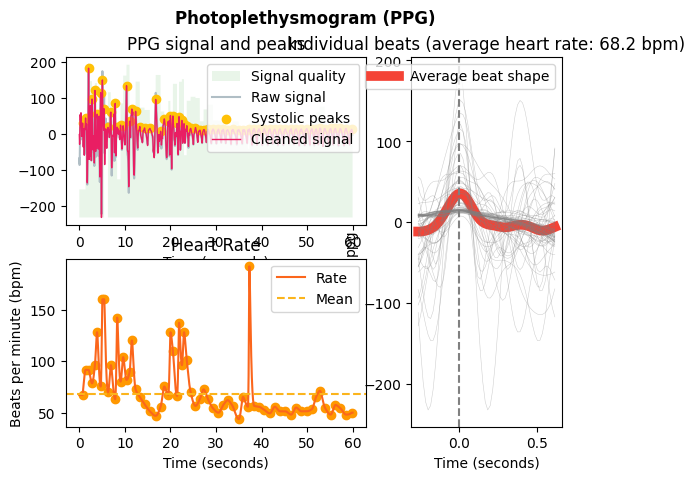

In [18]:
# Sanity check on a single window
segment = bvp_filtered[0:window_size]
signals, info = nk.ppg_process(segment, sampling_rate=fs_bvp)

print("Number of detected peaks:", len(info['PPG_Peaks']))
print("Window duration (sec):", window_sec)
print("Implied HR from peak count:", len(info['PPG_Peaks']) / window_sec * 60)
print("Mean PPG_Rate from signals:", signals['PPG_Rate'].mean())

# Plot to visually inspect
import matplotlib.pyplot as plt
nk.ppg_plot(signals, info)

plt.show()


In [19]:
# Manually inspect the actual RR intervals being used for RMSSD
peaks = info['PPG_Peaks']
print("Peak sample indices (first 10):", peaks[:10])

rr_intervals_samples = np.diff(peaks)
rr_intervals_ms = rr_intervals_samples / fs_bvp * 1000
print("RR intervals (ms):", rr_intervals_ms[:15])
print("Mean RR (ms):", rr_intervals_ms.mean())
print("Min/Max RR (ms):", rr_intervals_ms.min(), rr_intervals_ms.max())

Peak sample indices (first 10): [ 46  88 130 179 219 249 300 324 348 403]
RR intervals (ms): [656.25  656.25  765.625 625.    468.75  796.875 375.    375.    859.375
 625.    953.125 421.875 750.    578.125 734.375]
Mean RR (ms): 894.6496212121212
Min/Max RR (ms): 312.5 1375.0


In [20]:
def compute_rmssd(rr_ms):
    diff = np.diff(rr_ms)
    return np.sqrt(np.mean(diff**2))

rmssd_manual = compute_rmssd(rr_intervals_ms)
print("Manual RMSSD:", rmssd_manual)

Manual RMSSD: 251.04199914862545


In [21]:
# Try Elgendi method, which is specifically tuned for PPG (vs generic peak finding)
signals, info = nk.ppg_process(segment, sampling_rate=fs_bvp, method="elgendi")

peaks = info['PPG_Peaks']
rr_intervals_ms = np.diff(peaks) / fs_bvp * 1000
print("RR intervals (ms):", rr_intervals_ms[:15])
print("Mean RR:", rr_intervals_ms.mean())
print("Manual RMSSD:", compute_rmssd(rr_intervals_ms))

RR intervals (ms): [656.25  656.25  765.625 625.    468.75  796.875 375.    375.    859.375
 625.    953.125 421.875 750.    578.125 734.375]
Mean RR: 894.6496212121212
Manual RMSSD: 251.04199914862545


In [22]:
# Artifact-corrected approach
peaks_corrected = nk.signal_fixpeaks(peaks, sampling_rate=fs_bvp, method="kubios")[1]
rr_corrected_ms = np.diff(peaks_corrected) / fs_bvp * 1000

print("Corrected RR intervals (ms):", rr_corrected_ms[:15])
print("Mean RR:", rr_corrected_ms.mean())
print("Corrected RMSSD:", compute_rmssd(rr_corrected_ms))

Corrected RR intervals (ms): [656.25  656.25  765.625 625.    468.75  796.875 375.    375.    859.375
 625.    953.125 578.125 593.75  578.125 734.375]
Mean RR: 908.4134615384615
Corrected RMSSD: 204.40738526381728


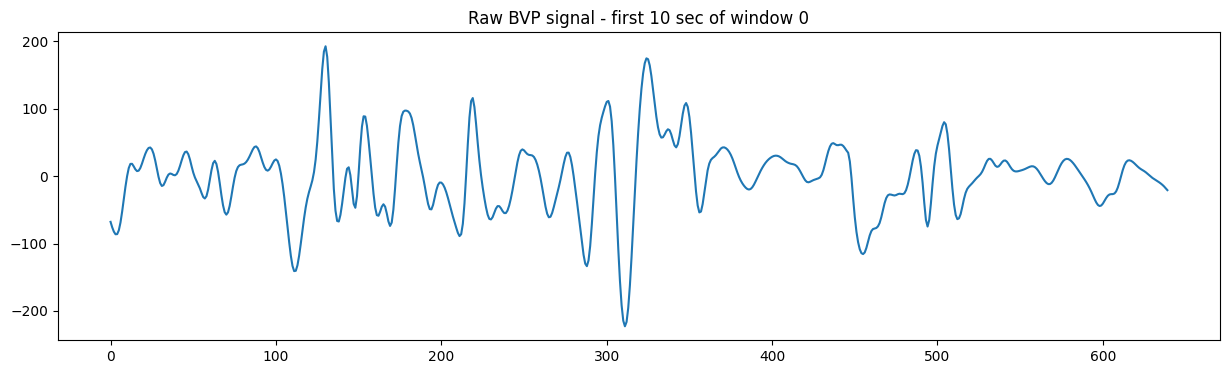

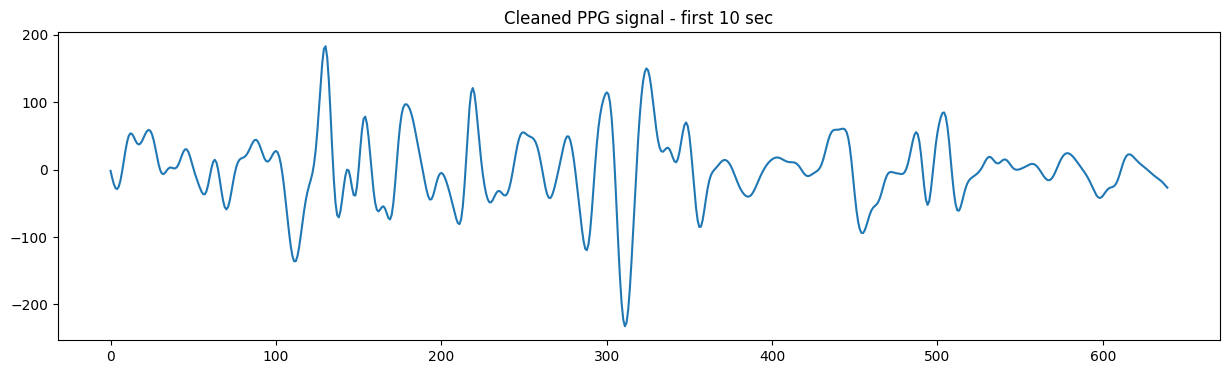

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(segment[:640])  # first 10 seconds
plt.title("Raw BVP signal - first 10 sec of window 0")
plt.show()

cleaned = nk.ppg_clean(segment, sampling_rate=fs_bvp)
plt.figure(figsize=(15,4))
plt.plot(cleaned[:640])
plt.title("Cleaned PPG signal - first 10 sec")
plt.show()

In [24]:
quality = nk.ppg_quality(cleaned, sampling_rate=fs_bvp)
print("Mean signal quality (0-1):", np.mean(quality))

peaks_dict = nk.ppg_findpeaks(cleaned, sampling_rate=fs_bvp, method="bishop")
peaks_bishop = peaks_dict['PPG_Peaks']
rr_bishop = np.diff(peaks_bishop) / fs_bvp * 1000
print("Bishop RR intervals:", rr_bishop[:15])
print("Bishop RMSSD:", compute_rmssd(rr_bishop))

Mean signal quality (0-1): 0.5342026270159852
Bishop RR intervals: [ 656.25   765.625  625.    1640.625 1859.375  953.125 1171.875 1312.5
 1171.875  828.125  921.875 1031.25  1171.875 1281.25  1875.   ]
Bishop RMSSD: 299.406832805486


In [25]:
peaks_dict = nk.ppg_findpeaks(cleaned, sampling_rate=fs_bvp, method="bishop")
peaks_bishop = peaks_dict['PPG_Peaks']
rr_bishop = np.diff(peaks_bishop) / fs_bvp * 1000
print("Bishop RR intervals:", rr_bishop[:15])
print("Bishop RMSSD:", compute_rmssd(rr_bishop))

Bishop RR intervals: [ 656.25   765.625  625.    1640.625 1859.375  953.125 1171.875 1312.5
 1171.875  828.125  921.875 1031.25  1171.875 1281.25  1875.   ]
Bishop RMSSD: 299.406832805486


In [26]:
features_list = []
labels_list = []
quality_list = []

for i in range(n_windows):
    start = i * step_size
    end = start + window_size
    segment_i = bvp_filtered[start:end]
    window_labels = label_filtered[start:end]
    window_label = np.bincount(window_labels).argmax()

    try:
        cleaned_i = nk.ppg_clean(segment_i, sampling_rate=fs_bvp)
        quality_i = np.mean(nk.ppg_quality(cleaned_i, sampling_rate=fs_bvp))

        if quality_i < 0.6:  # discard low-quality windows
            continue

        signals, info = nk.ppg_process(segment_i, sampling_rate=fs_bvp)
        peaks = info['PPG_Peaks']

        # artifact-correct the peaks
        peaks_corrected = nk.signal_fixpeaks(peaks, sampling_rate=fs_bvp, method="kubios")[1]
        rr_ms = np.diff(peaks_corrected) / fs_bvp * 1000

        # discard physiologically implausible RR intervals (HR range 40-180bpm => RR 333-1500ms)
        rr_ms = rr_ms[(rr_ms > 333) & (rr_ms < 1500)]

        if len(rr_ms) < 20:  # not enough beats for reliable HRV
            continue

        mean_hr = 60000 / rr_ms.mean()
        rmssd = compute_rmssd(rr_ms)
        sdnn = rr_ms.std()
        mean_nn = rr_ms.mean()
        pnn50 = np.sum(np.abs(np.diff(rr_ms)) > 50) / len(rr_ms) * 100

        features_list.append([mean_hr, rmssd, sdnn, mean_nn, pnn50])
        labels_list.append(window_label)
        quality_list.append(quality_i)

    except Exception as e:
        continue

print(f"Total windows: {n_windows}")
print(f"Windows passing quality filter: {len(features_list)}")

X = pd.DataFrame(features_list, columns=['mean_hr', 'rmssd', 'sdnn', 'mean_nn', 'pnn50'])
y = np.array(labels_list)

print(X.shape, y.shape)
print(X.describe())
print(np.unique(y, return_counts=True))

Total windows: 209
Windows passing quality filter: 191
(191, 5) (191,)
          mean_hr       rmssd        sdnn      mean_nn       pnn50
count  191.000000  191.000000  191.000000   191.000000  191.000000
mean    67.279069  279.469032  237.825472   909.555691   78.640316
std      9.832087   59.938285   37.707428   123.252547    7.571856
min     53.174043  105.973906   74.666956   644.791667   54.237288
25%     59.183356  233.425033  214.679287   821.112497   73.750000
50%     65.256373  286.256623  243.524491   919.450431   80.597015
75%     73.071644  324.370166  267.537043  1013.798701   83.636364
max     93.053312  403.828924  304.535017  1128.370098   94.444444
(array([0, 1, 2]), array([95, 33, 63]))


In [27]:
# Check sample-level timing resolution
print("Sample period at 64Hz:", 1000/64, "ms")

# Look at actual peak SAMPLE INDEX differences - are intervals suspiciously close to multiples of 15.6ms?
peaks_corrected_sample = peaks_corrected if 'peaks_corrected' in dir() else peaks
print("Peak indices (window 0):", peaks_corrected_sample[:15])

Sample period at 64Hz: 15.625 ms
Peak indices (window 0): [ 71 150 221 288 369 439 508 540 598 668 748 813 885 907 974]


In [28]:
from scipy.interpolate import interp1d

def interpolate_peaks(segment, fs_original, fs_target=256):
    n_original = len(segment)
    t_original = np.arange(n_original) / fs_original
    t_target = np.arange(0, t_original[-1], 1/fs_target)
    f = interp1d(t_original, segment, kind='cubic')
    return f(t_target)

# Test on window 0
segment_interp = interpolate_peaks(segment, fs_bvp, fs_target=256)
cleaned_interp = nk.ppg_clean(segment_interp, sampling_rate=256)
signals_interp, info_interp = nk.ppg_process(cleaned_interp, sampling_rate=256)

peaks_interp = info_interp['PPG_Peaks']
rr_interp_ms = np.diff(peaks_interp) / 256 * 1000
print("Interpolated RR intervals:", rr_interp_ms[:15])
print("Interpolated RMSSD:", compute_rmssd(rr_interp_ms))

Interpolated RR intervals: [ 351.5625   656.25     652.34375  769.53125  628.90625  484.375
  777.34375  378.90625 1230.46875  625.       945.3125   441.40625
  738.28125  582.03125  738.28125]
Interpolated RMSSD: 275.8049129094258


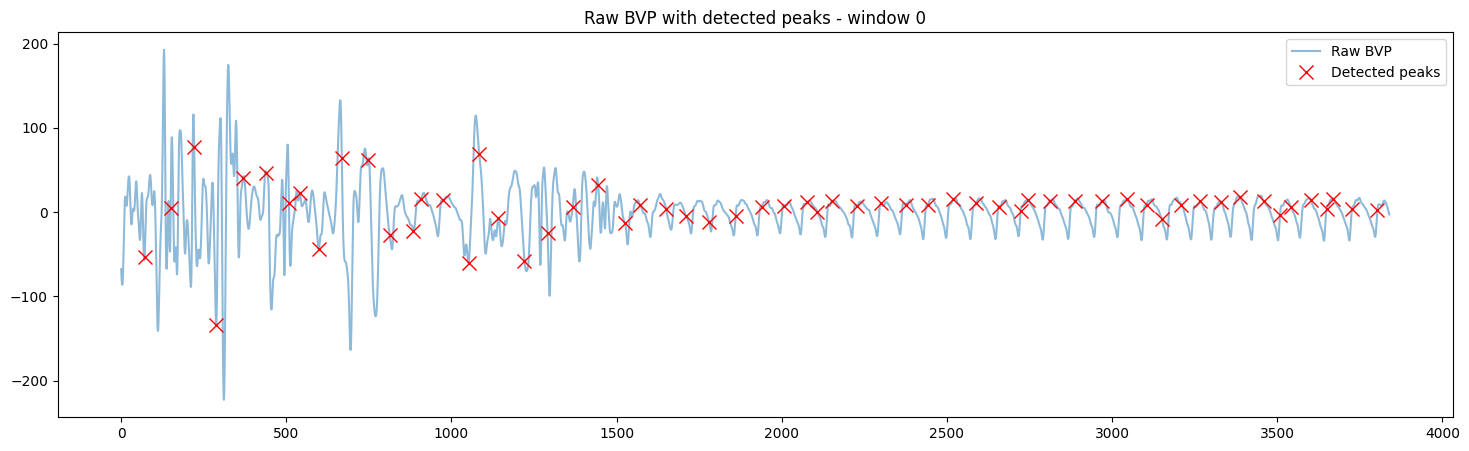

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))
plt.plot(segment, label='Raw BVP', alpha=0.5)
plt.plot(peaks, segment[peaks], 'rx', markersize=10, label='Detected peaks')
plt.legend()
plt.title('Raw BVP with detected peaks - window 0')
plt.show()

In [31]:
print(data['signal']['chest']['ECG'].dtype)
print(data['signal']['chest']['ECG'][:5])

float64
[[-0.75663757]
 [-0.70820618]
 [-0.67396545]
 [-0.53572083]
 [-0.32180786]]


In [32]:
import neurokit2 as nk
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

fs_ecg = 700
window_sec = 60
step_sec = 10
window_size = fs_ecg * window_sec
step_size = fs_ecg * step_sec

ecg = data['signal']['chest']['ECG'].flatten()
labels_700 = data['label']

label_map = {1: 0, 3: 1, 2: 2}
valid_labels = {1, 2, 3}

mask = np.isin(labels_700, list(valid_labels))
ecg_filtered = ecg[mask]
label_filtered_ecg = np.array([label_map[l] for l in labels_700[mask]])

print("Filtered ECG shape:", ecg_filtered.shape)
print(np.unique(label_filtered_ecg, return_counts=True))

n_windows = (len(ecg_filtered) - window_size) // step_size

features_list = []
labels_list = []

for i in range(n_windows):
    start = i * step_size
    end = start + window_size
    segment_i = ecg_filtered[start:end]
    window_labels = label_filtered_ecg[start:end]
    window_label = np.bincount(window_labels).argmax()

    try:
        signals, info = nk.ecg_process(segment_i, sampling_rate=fs_ecg)
        hrv = nk.hrv_time(signals, sampling_rate=fs_ecg, show=False)

        mean_hr = signals['ECG_Rate'].mean()
        rmssd = hrv['HRV_RMSSD'].values[0]
        sdnn = hrv['HRV_SDNN'].values[0]
        mean_nn = hrv['HRV_MeanNN'].values[0]
        pnn50 = hrv['HRV_pNN50'].values[0]

        if not (30 < mean_hr < 200) or not (5 < rmssd < 300):
            continue

        features_list.append([mean_hr, rmssd, sdnn, mean_nn, pnn50])
        labels_list.append(window_label)
    except Exception as e:
        continue

print(f"Total windows: {n_windows}")
print(f"Successful extractions: {len(features_list)}")

X = pd.DataFrame(features_list, columns=['mean_hr', 'rmssd', 'sdnn', 'mean_nn', 'pnn50'])
y = np.array(labels_list)

print(X.shape, y.shape)
print(X.describe())
print(np.unique(y, return_counts=True))

Filtered ECG shape: (1508500,)
(array([0, 1, 2]), array([798000, 262500, 448000]))
Total windows: 209
Successful extractions: 209
(209, 5) (209,)
          mean_hr       rmssd        sdnn      mean_nn       pnn50
count  209.000000  209.000000  209.000000   209.000000  209.000000
mean    64.472383  101.565197  119.156478   977.393320   51.968840
std     15.770376   35.576118   37.989642   190.634837   20.667515
min     50.615229   11.299300   41.689136   509.474969    0.000000
25%     53.707446   82.027436  101.925704   785.371429   38.461538
50%     55.127992  107.186873  116.679130  1089.100529   60.784314
75%     76.392117  128.098570  135.339974  1118.598901   67.307692
max    117.812180  175.432125  334.972686  1185.857143   77.358491
(array([0, 1, 2]), array([112,  34,  63]))


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:", np.unique(y_train, return_counts=True))
print("Test class distribution:", np.unique(y_test, return_counts=True))

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    class_weight='balanced',  # handles our class imbalance (112/34/63)
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Moderate', 'High']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nFeature Importances:")
for name, importance in zip(X.columns, rf_model.feature_importances_):
    print(f"{name}: {importance:.4f}")

Train shape: (167, 5) Test shape: (42, 5)
Train class distribution: (array([0, 1, 2]), array([90, 27, 50]))
Test class distribution: (array([0, 1, 2]), array([22,  7, 13]))

Accuracy: 0.8809523809523809

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.82      0.88        22
    Moderate       0.67      0.86      0.75         7
        High       0.93      1.00      0.96        13

    accuracy                           0.88        42
   macro avg       0.85      0.89      0.86        42
weighted avg       0.89      0.88      0.88        42


Confusion Matrix:
[[18  3  1]
 [ 1  6  0]
 [ 0  0 13]]

Feature Importances:
mean_hr: 0.2350
rmssd: 0.1159
sdnn: 0.1522
mean_nn: 0.2317
pnn50: 0.2651


In [34]:
joblib.dump(rf_model, 'stress_model.pkl')
print("Model saved as stress_model.pkl")

# Also save feature column order - Django will need this for inference
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'feature_columns.pkl')
print("Feature columns saved:", feature_columns)

Model saved as stress_model.pkl
Feature columns saved: ['mean_hr', 'rmssd', 'sdnn', 'mean_nn', 'pnn50']


In [35]:
loaded_model = joblib.load('stress_model.pkl')
sample = X_test.iloc[[0]]
print("Sample input:", sample.values)
print("True label:", y_test[0])
print("Predicted:", loaded_model.predict(sample))
print("Predicted probabilities:", loaded_model.predict_proba(sample))

Sample input: [[  51.85566115  111.77489725  107.46451619 1157.91428571   66.        ]]
True label: 0
Predicted: [0]
Predicted probabilities: [[0.92285858 0.07714142 0.        ]]


In [37]:
import os
print(os.listdir('files'))

['S3.pkl', 'S4.pkl', 'S5.pkl']


In [38]:
subject_files = {
    'S3': 'files/S3.pkl',
    'S4': 'files/S4.pkl',
    'S5': 'files/S5.pkl',
}

X_list = []
y_list = []
subject_id_list = []

for subj, path in subject_files.items():
    X_s, y_s = extract_subject_features(path)
    X_list.append(X_s)
    y_list.append(y_s)
    subject_id_list.append(np.full(len(y_s), subj))
    print(f"--- {subj} done ---\n")

X_combined = pd.concat(X_list, ignore_index=True)
y_combined = np.concatenate(y_list)
subject_ids = np.concatenate(subject_id_list)

print("Combined shape:", X_combined.shape, y_combined.shape)
print("Class distribution:", np.unique(y_combined, return_counts=True))
print("Subject distribution:", np.unique(subject_ids, return_counts=True))

NameError: name 'extract_subject_features' is not defined

In [39]:
import pickle
import numpy as np
import pandas as pd
import neurokit2 as nk
import warnings
warnings.filterwarnings('ignore')

def extract_subject_features(pkl_path, fs_ecg=700, window_sec=60, step_sec=10):
    with open(pkl_path, 'rb') as f:
        data_s = pickle.load(f, encoding='latin1')

    window_size = fs_ecg * window_sec
    step_size = fs_ecg * step_sec

    ecg = data_s['signal']['chest']['ECG'].flatten()
    labels_700 = data_s['label']

    label_map = {1: 0, 3: 1, 2: 2}
    valid_labels = {1, 2, 3}

    mask = np.isin(labels_700, list(valid_labels))
    ecg_filtered = ecg[mask]
    label_filtered_ecg = np.array([label_map[l] for l in labels_700[mask]])

    n_windows = (len(ecg_filtered) - window_size) // step_size

    features_list = []
    labels_list = []

    for i in range(n_windows):
        start = i * step_size
        end = start + window_size
        segment_i = ecg_filtered[start:end]
        window_labels = label_filtered_ecg[start:end]
        window_label = np.bincount(window_labels).argmax()

        try:
            signals, info = nk.ecg_process(segment_i, sampling_rate=fs_ecg)
            hrv = nk.hrv_time(signals, sampling_rate=fs_ecg, show=False)

            mean_hr = signals['ECG_Rate'].mean()
            rmssd = hrv['HRV_RMSSD'].values[0]
            sdnn = hrv['HRV_SDNN'].values[0]
            mean_nn = hrv['HRV_MeanNN'].values[0]
            pnn50 = hrv['HRV_pNN50'].values[0]

            if not (30 < mean_hr < 200) or not (5 < rmssd < 300):
                continue

            features_list.append([mean_hr, rmssd, sdnn, mean_nn, pnn50])
            labels_list.append(window_label)
        except Exception:
            continue

    X_s = pd.DataFrame(features_list, columns=['mean_hr', 'rmssd', 'sdnn', 'mean_nn', 'pnn50'])
    y_s = np.array(labels_list)

    print(f"{pkl_path}: {len(X_s)} windows extracted")
    print(np.unique(y_s, return_counts=True))

    return X_s, y_s


subject_files = {
    'S3': 'files/S3.pkl',
    'S4': 'files/S4.pkl',
    'S5': 'files/S5.pkl',
}

X_list = []
y_list = []
subject_id_list = []

for subj, path in subject_files.items():
    X_s, y_s = extract_subject_features(path)
    X_list.append(X_s)
    y_list.append(y_s)
    subject_id_list.append(np.full(len(y_s), subj))
    print(f"--- {subj} done ---\n")

X_combined = pd.concat(X_list, ignore_index=True)
y_combined = np.concatenate(y_list)
subject_ids = np.concatenate(subject_id_list)

print("Combined shape:", X_combined.shape, y_combined.shape)
print("Class distribution:", np.unique(y_combined, return_counts=True))
print("Subject distribution:", np.unique(subject_ids, return_counts=True))

files/S3.pkl: 209 windows extracted
(array([0, 1, 2]), array([112,  34,  63]))
--- S3 done ---

files/S4.pkl: 210 windows extracted
(array([0, 1, 2]), array([113,  38,  59]))
--- S4 done ---

files/S5.pkl: 215 windows extracted
(array([0, 1, 2]), array([117,  38,  60]))
--- S5 done ---

Combined shape: (634, 5) (634,)
Class distribution: (array([0, 1, 2]), array([342, 110, 182]))
Subject distribution: (array(['S3', 'S4', 'S5'], dtype='<U2'), array([209, 210, 215]))


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

unique_subjects = np.unique(subject_ids)
results = []

for test_subject in unique_subjects:
    train_mask = subject_ids != test_subject
    test_mask = subject_ids == test_subject

    X_train_loso = X_combined[train_mask]
    y_train_loso = y_combined[train_mask]
    X_test_loso = X_combined[test_mask]
    y_test_loso = y_combined[test_mask]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train_loso, y_train_loso)
    y_pred_loso = model.predict(X_test_loso)

    acc = accuracy_score(y_test_loso, y_pred_loso)
    results.append(acc)

    print(f"\n=== Test subject: {test_subject} ===")
    print(f"Train size: {len(y_train_loso)}, Test size: {len(y_test_loso)}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_loso, y_pred_loso, target_names=['Normal', 'Moderate', 'High'], zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_loso, y_pred_loso))

print("\n" + "="*50)
print(f"LOSO Mean Accuracy: {np.mean(results):.4f} (+/- {np.std(results):.4f})")
print(f"Per-subject accuracies: {dict(zip(unique_subjects, results))}")


=== Test subject: S3 ===
Train size: 425, Test size: 209
Accuracy: 0.8230
              precision    recall  f1-score   support

      Normal       0.77      0.98      0.86       112
    Moderate       0.33      0.03      0.05        34
        High       0.97      0.97      0.97        63

    accuracy                           0.82       209
   macro avg       0.69      0.66      0.63       209
weighted avg       0.76      0.82      0.76       209

Confusion Matrix:
[[110   0   2]
 [ 33   1   0]
 [  0   2  61]]

=== Test subject: S4 ===
Train size: 424, Test size: 210
Accuracy: 0.7524
              precision    recall  f1-score   support

      Normal       0.75      0.81      0.78       113
    Moderate       0.25      0.18      0.21        38
        High       0.98      1.00      0.99        59

    accuracy                           0.75       210
   macro avg       0.66      0.67      0.66       210
weighted avg       0.73      0.75      0.74       210

Confusion Matrix:
[[92 2

In [41]:
def normalize_by_subject_baseline(X, y, subject_ids):
    X_normalized = X.copy()
    
    for subj in np.unique(subject_ids):
        subj_mask = subject_ids == subj
        baseline_mask = subj_mask & (y == 0)  # Normal windows for this subject
        
        if baseline_mask.sum() == 0:
            print(f"Warning: no baseline windows for {subj}, skipping normalization for this subject")
            continue
        
        baseline_values = X[baseline_mask].mean()
        
        # percentage deviation from personal baseline
        for col in X.columns:
            X_normalized.loc[subj_mask, col] = (
                (X.loc[subj_mask, col] - baseline_values[col]) / baseline_values[col] * 100
            )
    
    return X_normalized


X_norm = normalize_by_subject_baseline(X_combined, y_combined, subject_ids)

print("Normalized feature stats:")
print(X_norm.describe())
print("\nSample comparison (first 5 rows):")
print("Raw:")
print(X_combined.head())
print("\nNormalized (% deviation from personal baseline):")
print(X_norm.head())

Normalized feature stats:
          mean_hr       rmssd        sdnn     mean_nn       pnn50
count  634.000000  634.000000  634.000000  634.000000  634.000000
mean    13.192280  -15.392654   -3.267781   -9.205579  -24.238082
std     21.886153   27.532489   28.731432   14.341272   40.254160
min     -8.504257  -90.559681  -66.264607  -53.532914 -100.000000
25%     -1.843334  -37.207355  -20.514765  -22.311922  -55.240722
50%      2.627429  -12.743907   -7.309252   -2.732904  -14.139506
75%     28.225638    4.720464   10.036927    1.478107    4.668031
max    113.949892   64.004810  171.064275    8.944663  123.528336

Sample comparison (first 5 rows):
Raw:
     mean_hr       rmssd        sdnn      mean_nn      pnn50
0  56.499353   99.846078  130.300350  1063.596939  62.500000
1  54.540610  109.063116   94.439222  1101.798942  68.518519
2  55.667274  111.935322  104.689809  1078.077922  67.272727
3  55.733433  107.186873  101.391329  1078.015873  68.518519
4  56.316889  121.190554  112.62826

In [42]:
results_norm = []

for test_subject in unique_subjects:
    train_mask = subject_ids != test_subject
    test_mask = subject_ids == test_subject

    X_train_norm = X_norm[train_mask]
    y_train_norm = y_combined[train_mask]
    X_test_norm = X_norm[test_mask]
    y_test_norm = y_combined[test_mask]

    model_norm = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42
    )
    model_norm.fit(X_train_norm, y_train_norm)
    y_pred_norm = model_norm.predict(X_test_norm)

    acc = accuracy_score(y_test_norm, y_pred_norm)
    results_norm.append(acc)

    print(f"\n=== Test subject: {test_subject} (normalized) ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_norm, y_pred_norm, target_names=['Normal', 'Moderate', 'High'], zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_norm, y_pred_norm))

print("\n" + "="*50)
print(f"LOSO Mean Accuracy (normalized): {np.mean(results_norm):.4f} (+/- {np.std(results_norm):.4f})")
print(f"Per-subject accuracies: {dict(zip(unique_subjects, results_norm))}")


=== Test subject: S3 (normalized) ===
Accuracy: 0.7751
              precision    recall  f1-score   support

      Normal       0.76      0.88      0.81       112
    Moderate       0.08      0.03      0.04        34
        High       0.94      1.00      0.97        63

    accuracy                           0.78       209
   macro avg       0.59      0.63      0.61       209
weighted avg       0.70      0.78      0.73       209

Confusion Matrix:
[[98 12  2]
 [31  1  2]
 [ 0  0 63]]

=== Test subject: S4 (normalized) ===
Accuracy: 0.6714
              precision    recall  f1-score   support

      Normal       0.79      0.78      0.79       113
    Moderate       0.25      0.39      0.30        38
        High       1.00      0.64      0.78        59

    accuracy                           0.67       210
   macro avg       0.68      0.61      0.62       210
weighted avg       0.75      0.67      0.70       210

Confusion Matrix:
[[88 25  0]
 [23 15  0]
 [ 0 21 38]]

=== Test subjec